## 掛載雲端硬碟


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 更改檔案所在路徑

In [2]:
# Change to your own folder !!!
%cd /content/drive/MyDrive/2025EAI/Lab2

/content/drive/MyDrive/2025EAI/Lab2


## Import library

In [3]:
import os
import argparse

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.autograd import Variable

from models.resnet import ResNet50

## FLOPs & Parameters & Architecture
若`resnet.py`有寫對，這部分會能夠正常跑，且 parameters 應為 23513162。

你也可以寫一個剪枝後可能的 cfg 作為模型的輸入參數，看這部分印出來的架構是否正確。

In [4]:
!pip install thop
!pip install torchsummary

In [5]:
from thop import profile
from torchsummary import summary

model = ResNet50(num_classes=10)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
model = model.to(device)

dummy_input = torch.randn(1, 3, 32, 32).to(device)
flops, params = profile(model, inputs=(dummy_input, ))

print(f"FLOPs: {flops}")
print(f"Params: {params}")
summary(model, input_size=(3, 32, 32))

Device: cuda
[INFO] Register count_convNd() for <class 'torch.nn.modules.conv.Conv2d'>.
[INFO] Register count_normalization() for <class 'torch.nn.modules.batchnorm.BatchNorm2d'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.activation.ReLU'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.pooling.MaxPool2d'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.container.Sequential'>.
[INFO] Register count_adap_avgpool() for <class 'torch.nn.modules.pooling.AdaptiveAvgPool2d'>.
[INFO] Register count_linear() for <class 'torch.nn.modules.linear.Linear'>.
FLOPs: 328947712.0
Params: 23513162.0
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,728
       BatchNorm2d-2           [-1, 64, 32, 32]             128
              ReLU-3           [-1, 64, 32, 32]               0
         MaxPool2d-4           [-1, 64, 16, 16]          

In [6]:
pruned_cfg = [64] + [32, 32, 256]*3 + [64, 64, 512]*4 + [128, 128, 1024]*6 + [256, 256, 2048]*3
pruned_model = ResNet50(num_classes=10, in_channels=3, cfg=pruned_cfg)
print(pruned_model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(32, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

## 設定超參數(請填空 λ)

In [7]:
SPARSITY_REGULARIZATION = True
#### 設定λ(balance factor) ####
################################################
#          請填空          #
################################################
LAMBDA = [0, 1e-5, 1e-4]

SEED = 1
TRAIN_BATCH_SIZE = 100
TEST_BATCH_SIZE = 1000

EPOCHS = 40
LEARNING_RATE = 1e-3

LOG_INTERVAL = 100
CUDA = True

RESUME = False
START_EPOCH = 0

WEIGHT_PATH = '/content/drive/MyDrive/2025EAI/Lab2/model_best.pth' # Change to your own folder !!!

In [8]:
if(torch.cuda.is_available()):
    CUDA = True
    kwargs = {'num_workers': 1, 'pin_memory': True}
    torch.cuda.manual_seed(SEED)
else:
    CUDA = False
    kwargs = {}


## 下載資料集


這裡將訓練集做Augmentation(Pad, RandCrop, Random)，測試集不用做Augmentation

In [9]:
#### 資料集 ####
train_loader = torch.utils.data.DataLoader(
    datasets.CIFAR10('./data', train=True, download=True,
                   transform=transforms.Compose([
                       transforms.Pad(4),
                       transforms.RandomCrop(32),
                       transforms.RandomHorizontalFlip(),
                       transforms.ToTensor(),
                       transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
                   ])),
    batch_size=TRAIN_BATCH_SIZE, shuffle=True, **kwargs)
test_loader = torch.utils.data.DataLoader(
    datasets.CIFAR10('./data', train=False, transform=transforms.Compose([
                       transforms.ToTensor(),
                       transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
                   ])),
    batch_size=TEST_BATCH_SIZE, shuffle=True, **kwargs)

## 定義模型與設定Optimizer & CrossEntropy Loss


In [10]:
model = ResNet50(num_classes=10)
if CUDA:
    model.cuda()

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

## 使用論文中稀疏化的方式更新參數(請填空)

In [11]:
def updateBN(lambda_val):
    for m in model.modules():
        if isinstance(m, nn.BatchNorm2d):
            #### 完成Sparsity Regularization ####
            ################################################
            #          請填空          #
            ################################################
            m.weight.grad.data.add_(lambda_val * torch.sign(m.weight.data))

## 定義訓練跟測試函數
需自行撰寫儲存每個epoch之train acc與test acc的code，以便後續繪製train acc與test acc結果圖!

In [12]:
#### 訓練函數 #####

# 注意: 需自行撰寫儲存每個epoch之train acc與test acc的code，以便後續繪製train acc與test acc結果圖!

def train(epoch, lambda_val):
    model.train()
    correct = 0
    total = 0

    for batch_idx, (data, target) in enumerate(train_loader):
        if CUDA:
            data, target = data.cuda(), target.cuda()

        data, target = Variable(data), Variable(target)

        optimizer.zero_grad()
        output = model(data)

        loss = criterion(output, target)
        loss.backward()

        if SPARSITY_REGULARIZATION:
            updateBN(lambda_val)
        optimizer.step()

        pred = output.data.max(1, keepdim=True)[1]
        correct += pred.eq(target.data.view_as(pred)).cpu().sum()
        total += target.size(0)

        if batch_idx % LOG_INTERVAL == 0:
            print('Train Epoch: {} [{}/{} ({:.1f}%)]\tLoss: {:.6f}'.format(
                epoch+1, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.data.item()))

    # Record training accuracy
    train_acc = 100. * correct / total
    print('Train set: Accuracy: {}/{} ({:.1f}%)\n'.format(correct, total, train_acc))
    return train_acc


#### 測試函數 ####
def test():
    model.eval()
    test_loss = 0
    correct = 0

    with torch.no_grad():
      for data, target in test_loader:
          if CUDA:
              data, target = data.cuda(), target.cuda()
          data, target = Variable(data), Variable(target)

          output = model(data)
          loss = criterion(output, target)
          test_loss += loss.item() * data.size(0)

          pred = output.data.max(1, keepdim=True)[1]
          correct += pred.eq(target.data.view_as(pred)).cpu().sum()

      test_loss /= len(test_loader.dataset)

      print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.1f}%)\n'.format(
          test_loss, correct, len(test_loader.dataset),
          100. * correct / len(test_loader.dataset)))
      return 100. * correct / len(test_loader.dataset)

##########################################################################################

train_acc_histories = {}
test_acc_histories = {}

for lambda_val in LAMBDA:
    print(f'\n{"="*50}')
    print(f'Training with LAMBDA = {lambda_val}')
    print(f'{"="*50}\n')

    # 重新初始化模型
    model = ResNet50(num_classes=10)
    if CUDA:
        model.cuda()

    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    train_acc_histories[lambda_val] = []
    test_acc_histories[lambda_val] = []
    best_prec1 = 0.

    for epoch in range(START_EPOCH, EPOCHS):
        # Learning Rate在0.5EPOCHS與0.75EPOCHS調整為原本1/10
        if epoch in [EPOCHS*0.5, EPOCHS*0.75]:
            for param_group in optimizer.param_groups:
                param_group['lr'] *= 0.1

        train_acc = train(epoch, lambda_val)
        test_acc = test()

        train_acc_histories[lambda_val].append(train_acc)
        test_acc_histories[lambda_val].append(test_acc)

        # 儲存模型權重，方便做後續剪枝,後續訓練
        if(test_acc > best_prec1):
            best_prec1 = test_acc
            torch.save({
                'epoch': epoch + 1,
                'state_dict': model.state_dict(),
                'best_prec1': best_prec1,
                'optimizer': optimizer.state_dict(),
            }, f'/content/drive/MyDrive/2025EAI/Lab2/model_best_lambda_{lambda_val}.pth')

        best_prec1 = max(test_acc, best_prec1)



Training with LAMBDA = 0

Train Epoch: 1 [0/50000 (0.0%)]	Loss: 2.394656
Train Epoch: 1 [10000/50000 (20.0%)]	Loss: 1.953090
Train Epoch: 1 [20000/50000 (40.0%)]	Loss: 1.677522
Train Epoch: 1 [30000/50000 (60.0%)]	Loss: 1.633466
Train Epoch: 1 [40000/50000 (80.0%)]	Loss: 1.716903
Train set: Accuracy: 16954/50000 (33.9%)


Test set: Average loss: 2.2292, Accuracy: 3144/10000 (31.4%)

Train Epoch: 2 [0/50000 (0.0%)]	Loss: 2.004329
Train Epoch: 2 [10000/50000 (20.0%)]	Loss: 1.554635
Train Epoch: 2 [20000/50000 (40.0%)]	Loss: 1.536287
Train Epoch: 2 [30000/50000 (60.0%)]	Loss: 1.216528
Train Epoch: 2 [40000/50000 (80.0%)]	Loss: 1.265594
Train set: Accuracy: 22425/50000 (44.8%)


Test set: Average loss: 1.5920, Accuracy: 4422/10000 (44.2%)

Train Epoch: 3 [0/50000 (0.0%)]	Loss: 1.411717
Train Epoch: 3 [10000/50000 (20.0%)]	Loss: 1.162199
Train Epoch: 3 [20000/50000 (40.0%)]	Loss: 1.153645
Train Epoch: 3 [30000/50000 (60.0%)]	Loss: 1.239919
Train Epoch: 3 [40000/50000 (80.0%)]	Loss: 1.31154

## 繪製Sparsity-Training結果圖

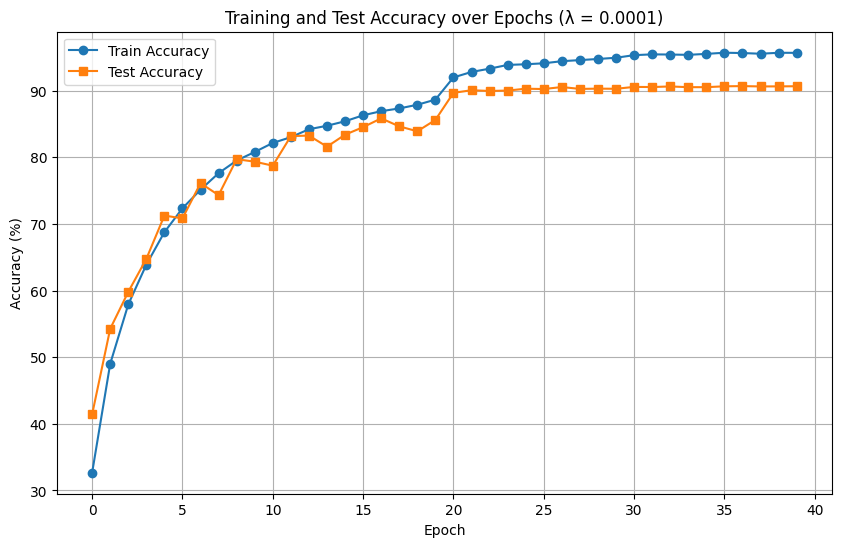

In [13]:
#繪製 Sparsity-Training 結果圖
import matplotlib.pyplot as plt
import numpy as np

lambda_val = 1e-4

plt.figure(figsize=(10, 6))
plt.plot(range(START_EPOCH, EPOCHS), train_acc_histories[lambda_val], label='Train Accuracy', marker='o')
plt.plot(range(START_EPOCH, EPOCHS), test_acc_histories[lambda_val], label='Test Accuracy', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title(f'Training and Test Accuracy over Epochs (λ = {lambda_val})')
plt.legend()
plt.grid(True)
plt.show()

## 繪製scaling factor 分布圖

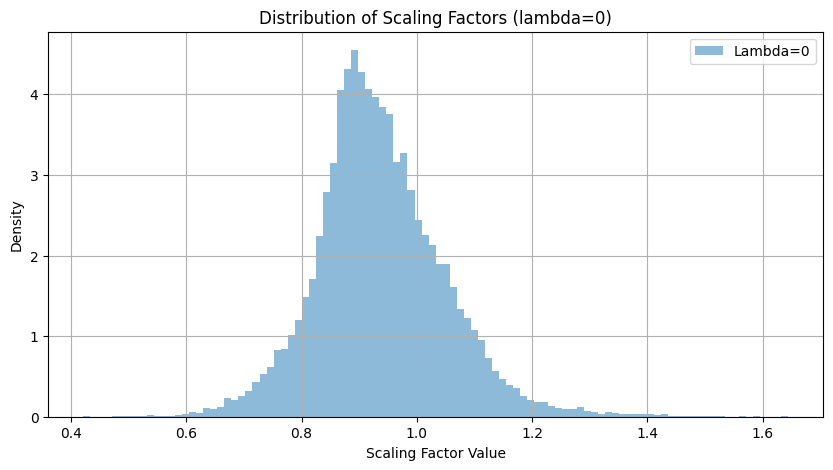

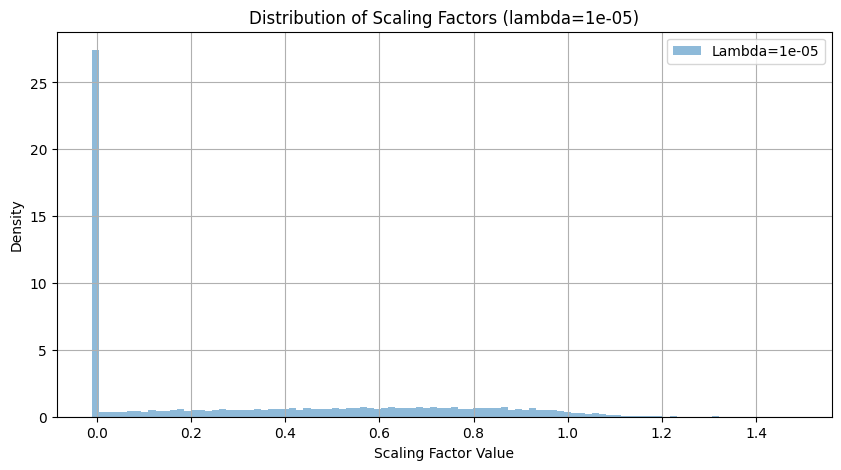

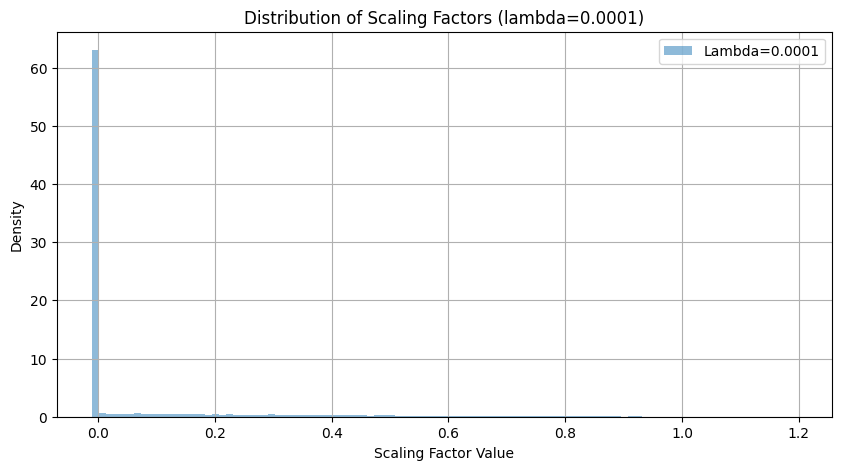

In [14]:
#繪製 scaling factor 分布圖
for lambda_val in LAMBDA:
    model = ResNet50(num_classes=10)
    if CUDA:
        model.cuda()
    checkpoint = torch.load(f'/content/drive/MyDrive/2025EAI/Lab2/model_best_lambda_{lambda_val}.pth')
    model.load_state_dict(checkpoint['state_dict'])

    scaling_factors = []
    for m in model.modules():
        if isinstance(m, nn.BatchNorm2d):
            scaling_factors.append(m.weight.data.cpu().numpy())
    scaling_factors = np.concatenate(scaling_factors)

    plt.figure(figsize=(10, 5))
    plt.hist(scaling_factors, bins=100, density=True, alpha=0.5, label=f'Lambda={lambda_val}')
    plt.xlabel('Scaling Factor Value')
    plt.ylabel('Density')
    plt.title(f'Distribution of Scaling Factors (lambda={lambda_val})')
    plt.legend()
    plt.grid(True)
    plt.show()